# A/B Testing : Testing Promotions in stores

# Import packages and dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.stats.power as smp
import scipy.stats as stats


/kaggle/input/datasets/chebotinaa/fast-food-marketing-campaign-ab-test/WA_Marketing-Campaign.csv


In [2]:
!pip install scikit-posthocs
import scikit_posthocs as sp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.3 MB/s eta 0:00:00


In [3]:
my_filepath = "/kaggle/input/datasets/chebotinaa/fast-food-marketing-campaign-ab-test/WA_Marketing-Campaign.csv"

#csv to dataframe
data = pd.read_csv(my_filepath)

# Data overview and pre-treatment

In [4]:
data.head(10)

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
5,1,Medium,2,5,2,2,34.67
6,1,Medium,2,5,2,3,27.98
7,1,Medium,2,5,2,4,27.72
8,1,Medium,3,12,1,1,44.54
9,1,Medium,3,12,1,2,37.94


In [5]:
data.dtypes

MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

In [6]:
data.isna().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

The dataset is clean : no duplicates, no nan values

We have the sales for each stores for four weeks. We are not interested in the fluctuation in the store sales across the weeks. Plus, it creates multiple lines for the same store. So I create a new metrics, avering the sales across thoses weeks.

In [8]:
condensed_data=data.groupby(["LocationID","MarketID","MarketSize","AgeOfStore","Promotion"])["SalesInThousands"].mean().reset_index(name="average_store_sales")
condensed_data.head()

,LocationID,MarketID,MarketSize,AgeOfStore,Promotion,average_store_sales
0,1,1,Medium,4,3,34.4200
1,2,1,Medium,5,2,29.5450
2,3,1,Medium,12,1,40.6800
3,4,1,Medium,1,2,33.7075
4,5,1,Medium,10,2,29.0025


In [9]:
# Convert the marketsize column into sorted Categorical type (easier to plot data later on in graphs)
condensed_data['MarketSize'] = pd.Categorical(
    condensed_data['MarketSize'],
    categories=['Small', 'Medium', 'Large'],
    ordered=True,
)

## Exploratory Data analysis

<Axes: xlabel='average_store_sales', ylabel='Count'>

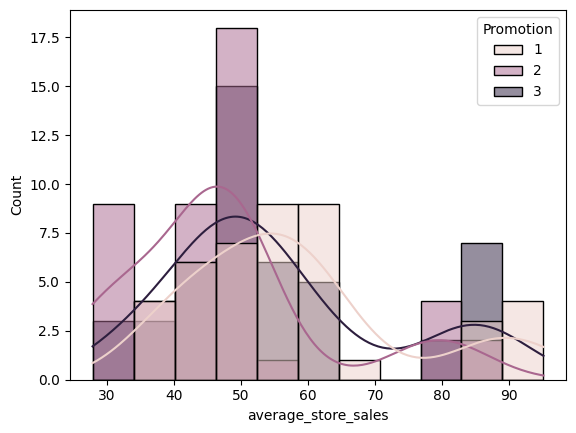

In [10]:
sns.histplot(
    condensed_data,
    x="average_store_sales",
    hue="Promotion",
    color="blue",
    kde=True,
    common_norm=True
)

These probability density curves are not normally distributed, they are bimodal. This is caused by stores with high average_store sales stores. Let's identify the independant variables that has an impact on the predicted variable average_store_sales 

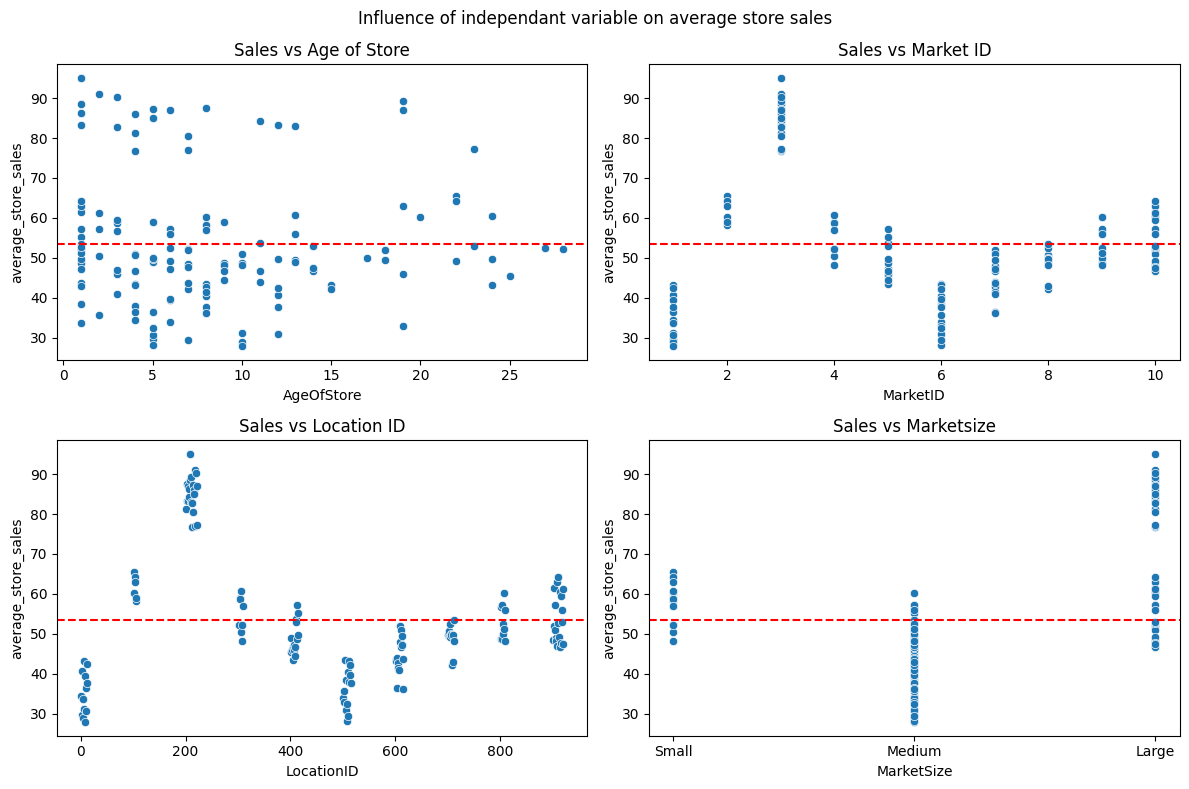

In [11]:
fig,ax=plt.subplots(2,2,figsize=(12, 8))
sns.scatterplot(
    data=condensed_data, 
    x='AgeOfStore', 
    y='average_store_sales',
    ax=ax[0,0]
)
ax[0, 0].axhline(condensed_data['average_store_sales'].mean(), color='red', linestyle='--')
ax[0, 0].set_title("Sales vs Age of Store")
sns.scatterplot(
    data=condensed_data, 
    x='MarketID', 
    y='average_store_sales',
    ax=ax[0,1]
)
ax[0, 1].axhline(condensed_data['average_store_sales'].mean(), color='red', linestyle='--')
ax[0, 1].set_title("Sales vs Market ID")

sns.scatterplot(
    data=condensed_data, 
    x='LocationID', 
    y='average_store_sales',
    ax=ax[1,0]
)

ax[1, 0].axhline(condensed_data['average_store_sales'].mean(), color='red', linestyle='--')
ax[1, 0].set_title("Sales vs Location ID")

sns.scatterplot(
    data=condensed_data, 
    x='MarketSize', 
    y='average_store_sales',
    ax=ax[1,1]
)

ax[1, 1].axhline(condensed_data['average_store_sales'].mean(), color='red', linestyle='--')
ax[1, 1].set_title("Sales vs Marketsize")

fig.suptitle("Influence of independant variable on average store sales")
# 3. Handle the 4th unused subplot (ax[1, 1])
plt.tight_layout()
plt.show()

<Axes: xlabel='average_store_sales', ylabel='Count'>

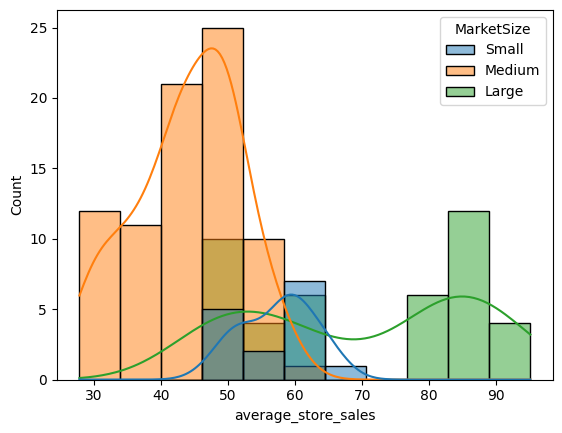

In [12]:
sns.histplot(
    condensed_data,
    x="average_store_sales",
    hue="MarketSize",
    kde=True,
    common_norm=True
)

The age of store doesn't appear to predict the average store_sales. We identify two clusters in the large market. And we identify a outliers on the LocationID/MarketId. Those two variables shows the same variation in data.

<Axes: xlabel='LocationID', ylabel='MarketID'>

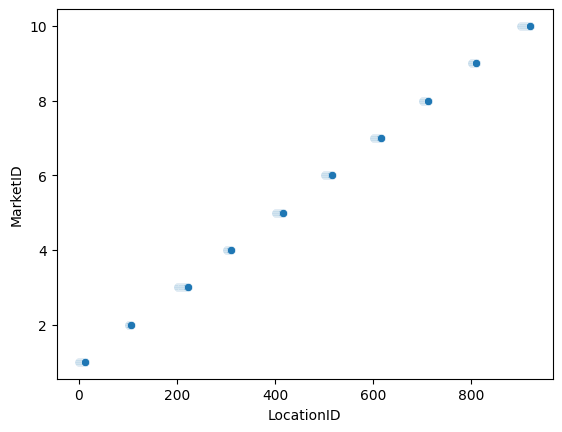

In [13]:
sns.scatterplot(data=condensed_data, 
    x='LocationID', 
    y='MarketID')

The locationID is directly related to the MarketID. So these two variables bring the same information. 

<Axes: xlabel='MarketID', ylabel='average_store_sales'>

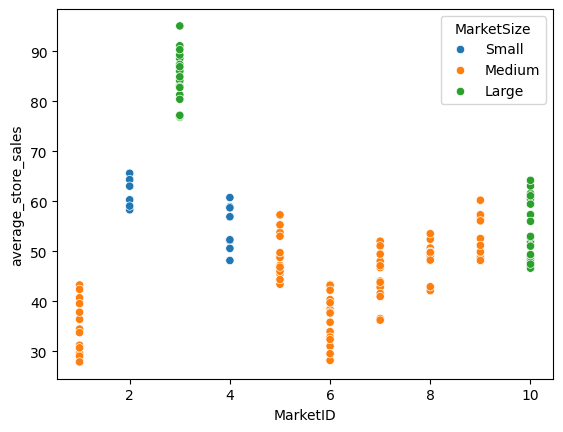

In [14]:
sns.scatterplot(
    data=condensed_data, 
    x='MarketID', 
    y='average_store_sales',
    hue='MarketSize')

Each MarketID belongs to one Marketsize category.
Stores which MarketID=3 overperform better compared to the others and could be considered as outliers. For now we will make analysis including the store and will check at the end if the results differ if we exclude the overperformer.

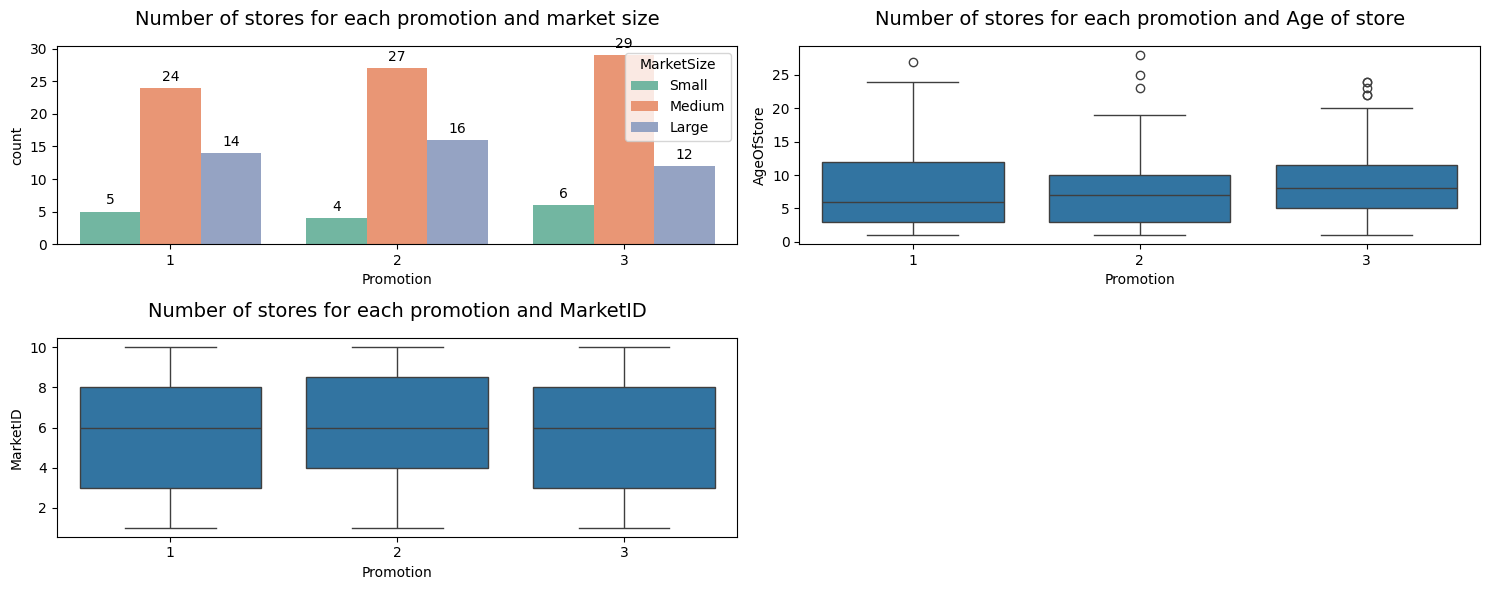

In [15]:
fig,ax=plt.subplots(2,2,figsize=(15, 6))

sns.countplot(
    data=condensed_data,
    x="Promotion",
    hue="MarketSize",
    palette="Set2",
    ax=ax[0,0]
)

ax[0,0].set_title("Number of stores for each promotion and market size", fontsize=14, pad=15)
# Label every bar group in the top-left subplot
for container in ax[0, 0].containers:
    ax[0, 0].bar_label(container, padding=3)
    
sns.boxplot(
    data=condensed_data,
    x="Promotion",
    y="AgeOfStore",
    ax=ax[0,1]
)
ax[0,1].set_title("Number of stores for each promotion and Age of store", fontsize=14, pad=15)

sns.boxplot(
    data=condensed_data,
    x="Promotion",
    y="MarketID",
    ax=ax[1,0]
)
ax[1,0].set_title("Number of stores for each promotion and MarketID", fontsize=14, pad=15)


fig.delaxes(ax[1, 1])  # Removes the empty subplot box

plt.tight_layout()
plt.show()

The distribution of market size, age of store and marketID seems to be homogeneous across the three promotions. But let's verify the statistically significant difference with statistic test.

## Check for the assignment biais

In [16]:
table=pd.pivot_table(data,index='Promotion',values='LocationID',aggfunc='nunique')
table

,LocationID
Promotion,
1,43
2,47
3,47


In [17]:
contingency_table=pd.crosstab(condensed_data['MarketSize'],condensed_data['Promotion'])
print(contingency_table)

Promotion    1   2   3
MarketSize            
Small        5   4   6
Medium      24  27  29
Large       14  16  12


### Chi-square test to check the market size sampling biais

Condition to use a Chi-square test : 
* Each cell count must have at least 5 expected cases : the count for the small market size is a bit too low to perform a Chi-square test but I will use it anyway.
* Each cases must be independant of all the other cases in the table --> True
  
The hypothesis are : 
* H0 : there is no difference in the proportion of market sizes in the different promotion groups --> the stores were randomly sampled and there was no market size biais.  
* Ha : there is at least a difference in one of the market size in the promotion groups --> there is a market size biais in how the stores were sampled.

In [18]:
chi2, p_val, dof, expected=stats.chi2_contingency(contingency_table,correction=False)
print("p-value: ",p_val)

p-value:  0.8799928219560625


With a significance level of $alpha=0.05$, we fail to reject the null hypothesis. So the randomization of store process successfully balanced the proportion of Large, Medium and Small markets across Promotion 1,2 and 3. 

### One-Way ANOVA test to check the age of stores sampling biais

Condition to use the ANOVA test : 
* the stores are independant across promotion groups and within each groups  --> True
* the average sales within each promotion group follows a normal distribution --> with 43-47 stores per promotion group, the distribution of the sample means of age of stores approaches a normal distribution (central limit theorem).
* The variability across the promotion group is about equal --> True (cf. table below)

Hypothesis :
* H0 : there is no difference in the means of age of stores across the three promotion groups.
* Ha : there is at least one difference

In [19]:
condensed_data.groupby('Promotion')['AgeOfStore'].agg(['mean','var','std','count'])

,mean,var,std,count
Promotion,,,,
1,8.279070,44.825028,6.695150,43
2,7.978723,44.238668,6.651216,47
3,9.234043,44.965772,6.705652,47


In [20]:
# Perform One-Way ANOVA
age_promo1=condensed_data[condensed_data['Promotion']==1]['AgeOfStore']
age_promo2=condensed_data[condensed_data['Promotion']==2]['AgeOfStore']
age_promo3=condensed_data[condensed_data['Promotion']==3]['AgeOfStore']
f_stat, p_val = stats.f_oneway(age_promo1, age_promo2, age_promo3)
print(f"p-value: {p_val:.3f}")

p-value: 0.639


P-value > 0.05 so we fail to reject the Null Hypothesis. 
So the randomization of store process successfully balanced the ages of store.

Same technique for the MarketID. I won't perform it here.

## Visualization of the campaign results

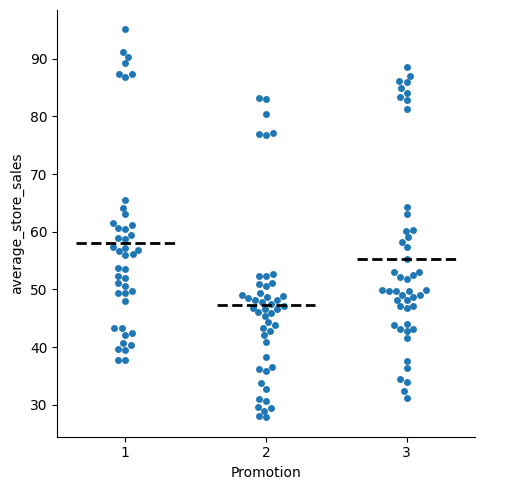

In [21]:
g=sns.catplot(condensed_data,x="Promotion",y="average_store_sales",kind="swarm")

# 2. Custom function to draw category-specific horizontal mean lines
def draw_group_means(data, **kws):
    # Calculate mean for each Promotion in the current MarketSize facet
    means = data.groupby("Promotion")["average_store_sales"].mean()

    # Loop through categories (0 = Promo 1, 1 = Promo 2, 2 = Promo 3)
    for i, (promo, mean_val) in enumerate(means.items()):
        plt.hlines(
            y=mean_val,
            xmin=i - 0.35,  # Span 35% to the left of the column center
            xmax=i + 0.35,  # Span 35% to the right of the column center
            colors="black",
            linestyles="--",
            linewidth=2,
            zorder=10       # Ensures line renders above swarm points
        )

# 3. Map the function across all MarketSize facets
g.map_dataframe(draw_group_means)

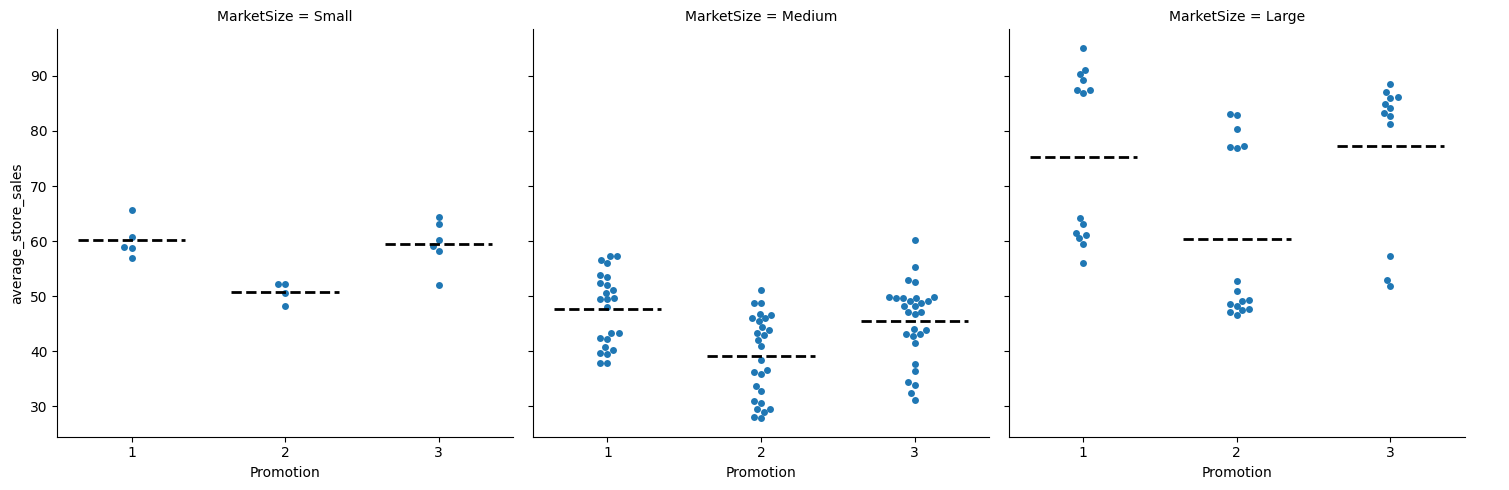

In [22]:
g=sns.catplot(condensed_data,x="Promotion",y="average_store_sales",col="MarketSize",kind="swarm")

# 2. Custom function to draw category-specific horizontal mean lines
def draw_group_means(data, **kws):
    
    # Calculate mean for each Promotion in the current MarketSize facet
    means = data.groupby("Promotion")["average_store_sales"].mean()

    # Loop through categories (0 = Promo 1, 1 = Promo 2, 2 = Promo 3)
    for i, (promo, mean_val) in enumerate(means.items()):
        plt.hlines(
            y=mean_val,
            xmin=i - 0.35,  # Span 35% to the left of the column center
            xmax=i + 0.35,  # Span 35% to the right of the column center
            colors="black",
            linestyles="--",
            linewidth=2,
            zorder=10       # Ensures line renders above swarm points
        )

# 3. Map the function across all MarketSize facets
g.map_dataframe(draw_group_means)

* For small and medium stores : The sales variance remains consistent across promotions. Promotion 2 shows lower overall effectiveness.
* For large stores : as we've seen above, the sales reveals two distinct performance tiers, a high performing group and a lower-performing group. Promotion 2 shows as well lower overall effectiveness.

In [23]:
condensed_data.groupby('Promotion')['average_store_sales'].agg(['mean','var','std','count'])

,mean,var,std,count
Promotion,,,,
1,58.099012,256.903927,16.028223,43
2,47.329415,210.165832,14.497097,47
3,55.364468,268.431054,16.383866,47


An easier way to compare the means for each market size for each promotion group is with a barplot.

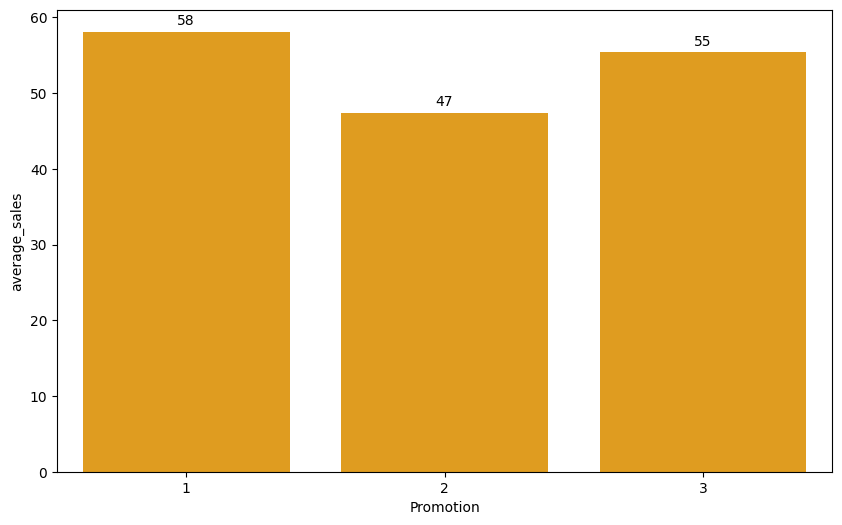

In [24]:
average_promotion=condensed_data.groupby('Promotion')['average_store_sales'].mean().reset_index(name='average_sales')

plt.figure(figsize=(10, 6))

ax=sns.barplot(
    data=average_promotion,
    x="Promotion",
    y="average_sales",
    color="orange"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

/tmp/ipykernel_58/3798066522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_market_promotion=condensed_data.groupby(['Promotion','MarketSize'])['average_store_sales'].mean().reset_index(name='average_marketsize_sales')
/tmp/ipykernel_58/3798066522.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:orange'` for the same effect.

  ax=sns.barplot(


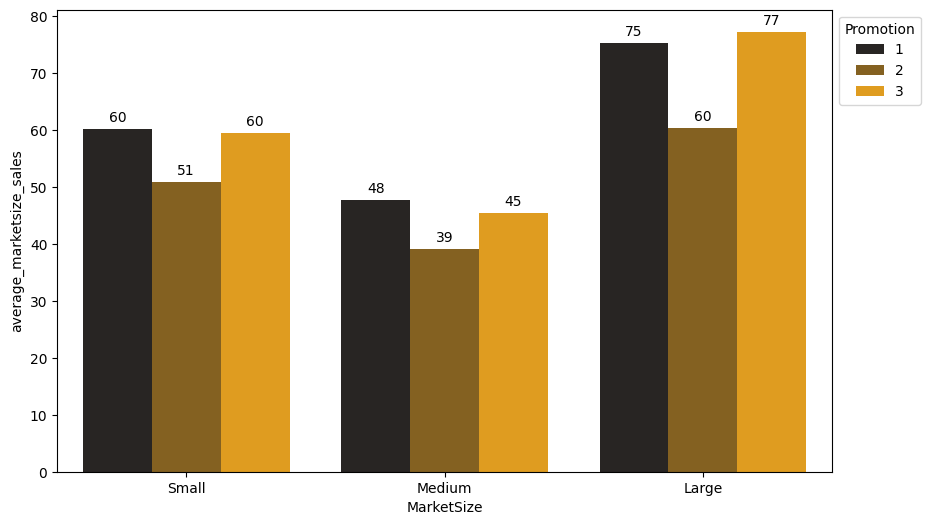

In [25]:
average_market_promotion=condensed_data.groupby(['Promotion','MarketSize'])['average_store_sales'].mean().reset_index(name='average_marketsize_sales')

plt.figure(figsize=(10, 6))

ax=sns.barplot(
    data=average_market_promotion,
    x="MarketSize",
    y="average_marketsize_sales",
    hue="Promotion",
    color="orange"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

On average, over the 4-week campaign experiment, Promotion 2 appears to underperform compared to Promotions 1 and 3 across all market sizes. Next, I will run a hypothesis test to determine whether there is a statistically difference between the means or if this variation is simply due to random chance.

## Hypothesis thesis

In [26]:
len(condensed_data)

137

In our dataset, the dependent (response) variable is average_store_sales, and the independent variables used to explain its variance are C(Promotion), AgeOfStore, C(MarketID), and C(MarketSize), where C() denotes categorical variables.

As established above, MarketID inherently contains information about MarketSize. Because these two variables are highly collinear, I will only include MarketID in the primary model. It captures more information by accounting for both market size and local market specificities. This eliminates most of the noise linked to differences in market location and size, granting the highest statistical power (by minimizing residual variance) to determine the best overall promotion.

If we wanted to compare promotion performance specifically across market sizes, I would instead use MarketSize as a covariate, where the model coefficients will reflect the sales differences between market sizes.

To maximize statistical power, I will perform an ANOVA/ANCOVA on the $N = 137$ store-level data points ( len(condensed_data) ).

**ANOVA/ANCOVA Assumptions Check:Independence**:   
* The stores are independent $\rightarrow$ Met  
* Normality of Residuals: The residual errors follow a normal distribution $\rightarrow$ Met (with n=43/45 stores per promotion group (n>30), the Central Limit Theorem guarantees that the sample means are normally distributed thus the residuals). I will check at the end the normality of the residuals with a Q-Q plot.
* Homogeneity of Variances: Residual variance across all promotion groups is roughly equal $\rightarrow$ Met (confirmed via Levene’s test)

Levene Test :

The Null hypothesis in the Levene test is : there is no difference in the variance. 

In [28]:
p1 = condensed_data[condensed_data['Promotion'] == 1]['average_store_sales']
p2 = condensed_data[condensed_data['Promotion'] == 2]['average_store_sales']
p3 = condensed_data[condensed_data['Promotion'] == 3]['average_store_sales']


# Levene Test
stat, p_levene = stats.levene(p1, p2, p3)
print(f"Levene p-value : {p_levene:.4f}")

Levene p-value : 0.6272


With a significance level of 0.05, we fail to reject the Levene Null hypothesis. It means that we can consider that the variances between the groups are not significantly different, the variance are homogenous.

I will compare different linear model to identity variables that explain variance in the predicted variable.

In [29]:
model1 = smf.ols('average_store_sales ~ C(Promotion)', data=condensed_data).fit()
model2 = smf.ols('average_store_sales ~ C(Promotion)+ C(MarketID)', data=condensed_data).fit()
model3 = smf.ols('average_store_sales ~ C(Promotion)+ C(MarketSize)', data=condensed_data).fit()
model4 = smf.ols('average_store_sales ~ C(Promotion)+ C(MarketSize)+ AgeOfStore', data=condensed_data).fit()
print(f"""
    Model 1 Adj. R2: {model1.rsquared_adj:.3f}
    Model 2 Adj. R2: {model2.rsquared_adj:.3f}
    Model 3 Adj. R2: {model3.rsquared_adj:.3f}
    Model 4 Adj. R2: {model4.rsquared_adj:.3f}
""")


    Model 1 Adj. R2: 0.067
    Model 2 Adj. R2: 0.974
    Model 3 Adj. R2: 0.614
    Model 4 Adj. R2: 0.612



In [30]:
data['MarketID'].nunique()

10

**MarketID**: Including MarketID captures most of the variance in average_store_sales, causing the adjusted $R^2$ to jump artificially above $90\%$. This leads to severe overfitting, as the model absorbs hyper-local differences rather than generalizable patterns.

**AgeOfStore**: Incorporating AgeOfStore into Model 4 yields no additional explanatory power, leaving the adjusted $R^2$ identical to Model 3.

**Model Choice**: I selected MarketSize as the control variable for the final specification (Model 3). It effectively neutralizes market size differences using only three categories (consuming 2 degrees of freedom) instead of 10 distinct market IDs (which would consume 9 degrees of freedom). This approach minimizes parameter penalty, preserves residual degrees of freedom, and maintains high statistical power without inflating the critical $F$-value.

In [48]:
anova_table = sm.stats.anova_lm(model3)

print(f"""
linear regression_summary:
{model3.summary()}

anova_table:
{anova_table}
""")


linear regression_summary:
                             OLS Regression Results                            
Dep. Variable:     average_store_sales   R-squared:                       0.626
Model:                             OLS   Adj. R-squared:                  0.614
Method:                  Least Squares   F-statistic:                     55.14
Date:                 Fri, 09 Oct 2026   Prob (F-statistic):           2.94e-27
Time:                         06:04:36   Log-Likelihood:                -508.10
No. Observations:                  137   AIC:                             1026.
Df Residuals:                      132   BIC:                             1041.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

The Global F-test for the **overall Model Null Hypothesis** (cf. model.summary):  
H0 : all group parameters equal zero; none of the predictors in the model explain any variance in the outcome variable. The model is no better at predicting sales than simply using the global average of sales --> SSR (simpler model with only the global average mean and without predictors = SSR (fancier model with predictors)
Prob (F-statistic) = 2.94e-27 <<0. So we are very confident to reject the Null hypothesis. At least one of the predictor significantly reduces residual error SSR. 

The Partial F-test for the **individual factor Null Hypothesis** (cf. Anova_table) :  
For `Promotion` : $H0^\text{Promotion}$ : after controlling for MarketSize, there is no difference in average sales across promotion ($\mu_\text{prom1}=\mu_\text{prom2}=\mu_\text{prom3}$)
p-value for C(Promotion)= 2.7e-6 << 0.05. So with a significance level of $\alpha$=0.05, we are confident to reject the Null Hypothesis. It means that there is a satistically significant difference in the mean between the promotion groups. Thus, at least one of the promotion has an impact of the sales result.

Let's conduct post-hoc paired-t-testing to identify which promotion group leads to statistically significant sales differences.

In [32]:
post_hoc_table=sp.posthoc_ttest(condensed_data, ## the DataFrame that has our data
                 val_col="average_store_sales", ## column with the values
                 group_col="Promotion", ## column that defines how the values should be grouped
                 pool_sd=True, ## pool all data to estimate standard deviation
                 equal_var=True, ## assume variances are the same for each group.
                 p_adjust='holm') ## multiple testing correction
print(post_hoc_table)

          3         2         1
3  1.000000  0.028037  0.409039
2  0.028037  1.000000  0.004214
1  0.409039  0.004214  1.000000


The p-value calculation shows that the **difference between Promotion 1 and 3 is not statistically significant** (p-value=0.4).  
**Promotion 2 is significantly different from Promotion 1 and Promotion 3**.
We need to look at the regression to determine how Promotion 2 differs from Promotion 1.

In [33]:
data_no_outliers=condensed_data[condensed_data['MarketID']!=3]
model_no_outliers = smf.ols('average_store_sales ~ C(Promotion) +C(MarketSize)', data=data_no_outliers).fit()
print(f"""
    Model with outliers Adj. R2: {model3.rsquared_adj:.3f}
    model_no_outliers Adj. R2: {model_no_outliers.rsquared_adj:.3f}
    """)
print("Model with outliers 2 Coef:", model3.params['C(Promotion)[T.2]'])
print("model_no_outliers 2 Coef:", model_no_outliers.params['C(Promotion)[T.2]'])


    Model with outliers Adj. R2: 0.614
    model_no_outliers Adj. R2: 0.533
    
Model with outliers 2 Coef: -10.76740811186618
model_no_outliers 2 Coef: -9.3572692779182


To ensure the results were not distorted by high-performing outlier stores (MarketID=3), I compared a model with the outliers and without outliers. The treatment effect for Promotion 2 remained relatively unchanged, demonstrating that the conclusion of the model with outliers is robust. 

In [34]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     average_store_sales   R-squared:                       0.626
Model:                             OLS   Adj. R-squared:                  0.614
Method:                  Least Squares   F-statistic:                     55.14
Date:                 Fri, 09 Oct 2026   Prob (F-statistic):           2.94e-27
Time:                         05:50:10   Log-Likelihood:                -508.10
No. Observations:                  137   AIC:                             1026.
Df Residuals:                      132   BIC:                             1041.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  60.6869      2.879     21.077      0.000      54.991      66.382
C(Promotion)[T.2]         -10.7674      2.124     -5.069      0.000     -14.970      -6.565
C(Promotion)[T.3]          -1.0156      2.127     -0.478      0.634      -5.222       3.191
C(MarketSize)[T.Medium]   -12.6994      2.833     -4.483      0.000     -18.303      -7.095
C(MarketSize)[T.Large]     13.8219      3.035      4.554      0.000       7.819      19.825
==============================================================================
Omnibus:                       10.289   Durbin-Watson:                   0.292
Prob(Omnibus):                  0.006   Jarque-Bera (JB):                4.228
Skew:                          -0.114   Prob(JB):                        0.121
Kurtosis:                       2.170   Cond. No.                         7.18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
param=model3.params
beta0=param['Intercept']
beta2=param['C(Promotion)[T.2]']
mean2=beta0+beta2
increase=-beta2/mean2 *100

CI=model3.conf_int()


CI_infbeta2=CI[0]['C(Promotion)[T.2]']
CI_supbeta2=CI[1]['C(Promotion)[T.2]']

CI_infbeta0=CI[0]['Intercept']
CI_supbeta0=CI[1]['Intercept']

CI_inf_increase=-CI_supbeta2/(CI_supbeta2+CI_infbeta0)*100
CI_sup_increase=-CI_infbeta2/(CI_supbeta2+CI_supbeta0)*100

print(f"The Promotion 1 generates an estimated +{-beta2:.0f}$K additional revenue per store compared to Promotion 2 (95%CI:[{-CI_supbeta2:.2f}$K;{-CI_infbeta2:.2f}$K]), representing an average lift of {increase:.0f}% (95%CI:[{CI_inf_increase:.0f}%;{CI_sup_increase:.0f}%]")

The Promotion 1 generates an estimated +11$K additional revenue per store compared to Promotion 2 (95%CI:[6.57$K;14.97$K]), representing an average lift of 22% (95%CI:[14%;25%]


# Checking model conditions using graphs

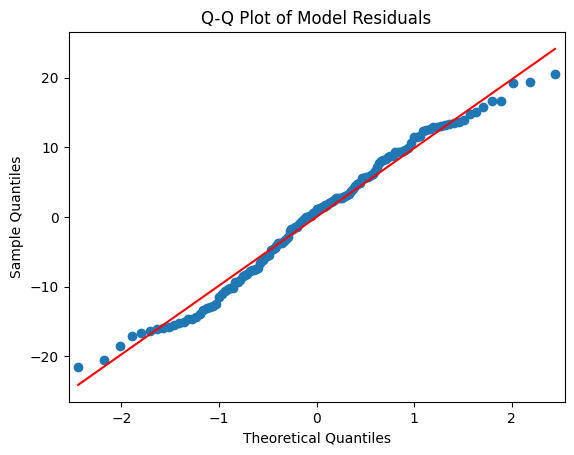

/tmp/ipykernel_58/2108477961.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/2108477961.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


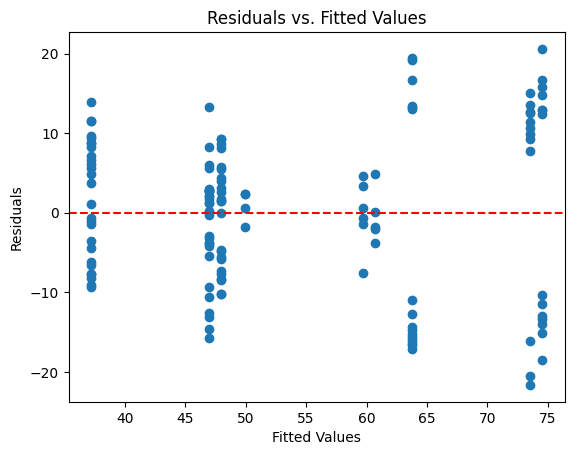

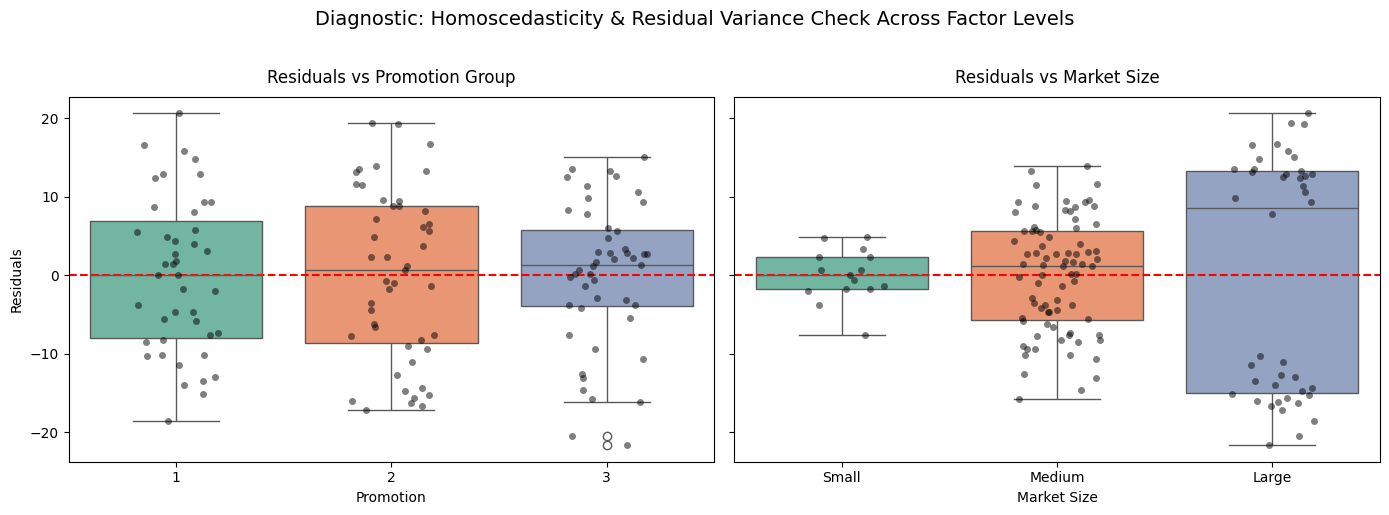

In [49]:
residuals = model3.resid
fitted=model3.fittedvalues

# 3. Generate Q-Q plot of the residuals
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Model Residuals")
plt.show()

# 4. Check Linearity and Homoscedasticity
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")

# 2. Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Subplot 1: Residuals vs Promotion
sns.boxplot( 
    x=condensed_data['Promotion'], 
    y=residuals, 
    ax=axes[0], 
    palette='Set2'
)
sns.stripplot( 
    x=condensed_data['Promotion'], 
    y=residuals, 
    ax=axes[0], 
    color='black', 
    alpha=0.5, 
    jitter=0.2
)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Promotion Group', fontsize=12, pad=10)
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('Residuals')

# Subplot 2: Residuals vs MarketSize
sns.boxplot( 
    x=condensed_data['MarketSize'], 
    y=residuals, 
    ax=axes[1], 
    palette='Set2'
)
sns.stripplot( 
    x=condensed_data['MarketSize'], 
    y=residuals, 
    ax=axes[1], 
    color='black', 
    alpha=0.5, 
    jitter=0.2
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Market Size', fontsize=12, pad=10)
axes[1].set_xlabel('Market Size')
axes[1].set_ylabel('')  # Shared y-axis

plt.suptitle('Diagnostic: Homoscedasticity & Residual Variance Check Across Factor Levels', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


plt.show()

## Power analysis

Let's have a little dig into the power analysis of what we've performed above.

In [37]:
#Calculate the f_min of ANOVA test for a given power and alpha
alpha=0.05
power=0.80
k=3
f_min = smp.FTestAnovaPower().solve_power(
    effect_size=None,
    k_groups=k,
    nobs=len(condensed_data),
    alpha=alpha,
    power=power
)

Convert $f_\text{min}$ to $\Delta_\text{max}=MDE$, the dollar difference between the best and the worst promotion (the two extreme group average sales)
$$\Delta_\text{max} = f_\text{min} \times \sqrt{2 \times k} \times \sigma_\text{resid}$$

In [38]:
std_resid=np.sqrt(model3.mse_resid)
delta_max=f_min*np.sqrt(2*k)*std_resid
print(f"""
The minimum detectable dollar difference between the best and the worst promotion is: {delta_max:.1f}k$ per store.
In other words, considering the number of stores in the promotion campaign, the experiment design was sensitive enough to detect any average sales gap greater than or equal to {delta_max:.1f}k$. 
""")


The minimum detectable dollar difference between the best and the worst promotion is: 6.6k$ per store.
In other words, considering the number of stores in the promotion campaign, the experiment design was sensitive enough to detect any average sales gap greater than or equal to 6.6k$. 



In [39]:
#Calculate the d_min of pairwise t-test for a given power and alpha
alpha=0.05
power=0.80
d_min = smp.TTestIndPower().solve_power(
    effect_size=None,
    nobs1=(condensed_data['Promotion']==1).sum(),
    alpha=alpha,
    power=power
)

Convert $d_\text{min}$ to $MDE$, the minimum dollar difference between two groups.
$$\Delta = d_\text{min} \times \sigma_\text{resid}$$

In [40]:
delta=d_min*std_resid
print(f'The minimum detectable dollar difference between any two promotion is: {delta:.1f}k$ per store')
#define baseline sales
baseline_sales=condensed_data['average_store_sales'].mean()
delta_perc=(delta/baseline_sales)*100
print(f'The promotion campaign has a {power*100:.0f}% chance of detecting any true sales uplift of {delta_perc:.1f}% or greater')

The minimum detectable dollar difference between any two promotion is: 6.1k$ per store
The promotion campaign has a 80% chance of detecting any true sales uplift of 11.5% or greater


## Additional analysis

Since the beginning I averaged the sales across 4 weeks campaign. Let's have a look now on the sales for each week to check for promotional fatigue or novelty biais. I could bring additionnal information about the stability of Promotions over time.

<Axes: xlabel='Promotion', ylabel='SalesInThousands'>

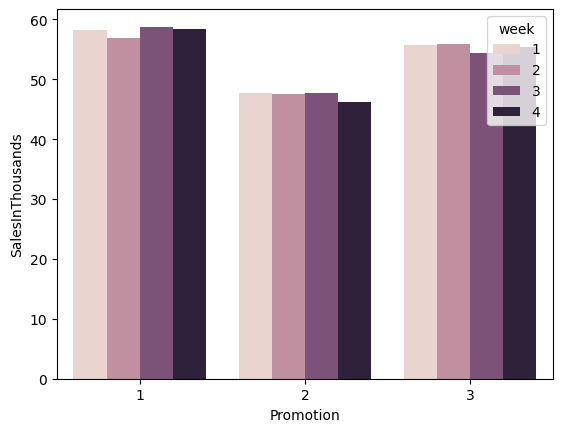

In [41]:
sns.barplot(data,x='Promotion',y='SalesInThousands',hue='week',errorbar=None)

The promotions are stable over the 4-week campaign.

# Notes on Method & Power Analysis

**Covariate Selection & Model Fit**:  
I evaluated multiple model specifications to include only predictors that explain meaningful variance in average_sales. Each added covariate ($c$) reduces the residual degrees of freedom by 1:$$\text{df}_{\text{resid}} = N - k - c$$

While losing a degree of freedom slightly lowers statistical power, adding a relevant covariate significantly reduces the Sum of Squared Errors ($\text{SSE}$). Because the reduction in residual variance ($\text{MSE}_{\text{resid}}$) outweighs the loss in degrees of freedom, the overall effect size ($f$) and power increase:$$\text{MSE}_{\text{resid}} = \frac{\text{SSE}}{\text{df}_{\text{resid}}}$$$$f = \frac{\sigma_{\mu}}{\sigma_{\text{resid}}} = \sqrt{\frac{\sum_{i=1}^{k} (\mu_i - \mu)^2}{k \cdot \text{MSE}_{\text{resid}}}}$$

**Pooled Analysis vs. Subgroup Analysis**:  
It was critical to analyse all stores in a single ANCOVA model rather than splitting the dataset by MarketSize. While subsetting would reduce variance within each subgroup, it would drop the sample size to $N \approx 43\text{--}45$ per segment, severely reducing statistical power. Controlling for MarketSize as a covariate in the full model ($N=137$) achieves the best of both worlds: it lowers residual variance while preserving sample size and power. 

**Business Decision (P1 vs. P3)**:  
Because Promotion 1 and Promotion 3 show no statistically significant difference in sales lift and seem to be quite stable over time, the choice between them should depend on implementation costs and operational feasibility.

**Data Limitations & Future Improvements**:
Having pre-promotion baseline sales per store would have allowed a paired analysis to measure the exact lift relative to each store's baseline. It would have eliminated between-store variances. With the paired t-test, I would have calculated $\Delta = Sales_\text{promoted} - Sales_{baseline}$, which evaluates incremental growth without including pre-existing structural differences.